# 📊 EDA — Rural Carbon Dataset

**File:** `rural_carbon_dataset1.csv`  
**Rows:** 3,000 | **Columns:** 13  
**Description:** Rural carbon emission data across regions, months, crop types, livestock, energy usage, and climate variables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data


In [2]:
from pathlib import Path

raw = Path('../data/raw')
df = pd.read_csv(raw / 'rural_carbon_dataset1.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (3000, 13)


,Region,Month,Fertilizer_Usage_kg,Crop_Type,Crop_Area_ha,Livestock_Cows,Livestock_Pigs,Household_Energy_kWh,Renewable_Energy_Fraction,Temperature_C,Rainfall_mm,Carbon_Emission_tCO2,Year
0,R0103,4,106.5,Maize,37.3,0,130,296.6,0.58,23.6,70.7,5.91,2024
1,R0271,11,100.9,Wheat,47.4,95,196,408.8,0.50,24.9,275.5,21.63,2021
2,R0107,7,59.4,Maize,28.7,83,120,479.3,0.97,21.8,35.7,9.24,2022
3,R0072,8,122.9,Rice,29.3,53,82,146.3,0.13,30.7,285.5,3.71,2024
4,R0189,2,66.4,Maize,25.7,46,169,233.9,0.90,23.3,76.2,4.37,2020


## 2. Basic Information


In [3]:
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Region                     3000 non-null   object 
 1   Month                      3000 non-null   int64  
 2   Fertilizer_Usage_kg        3000 non-null   float64
 3   Crop_Type                  3000 non-null   object 
 4   Crop_Area_ha               3000 non-null   float64
 5   Livestock_Cows             3000 non-null   int64  
 6   Livestock_Pigs             3000 non-null   int64  
 7   Household_Energy_kWh       3000 non-null   float64
 8   Renewable_Energy_Fraction  3000 non-null   float64
 9   Temperature_C              3000 non-null   float64
 10  Rainfall_mm                3000 non-null   float64
 11  Carbon_Emission_tCO2       3000 non-null   float64
 12  Year                       3000 non-null   int64  
dtypes: float64(7), int64(4), object(2)
memory usage:

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,3000,300,R0039,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,3000.0,NaN,NaN,NaN,6.606,3.441615,1.0,4.0,7.0,10.0,12.0
Fertilizer_Usage_kg,3000.0,NaN,NaN,NaN,124.144067,43.261874,50.0,86.7,122.85,161.625,199.9
Crop_Type,3000,4,Rice,774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Area_ha,3000.0,NaN,NaN,NaN,27.702533,12.980907,5.0,16.575,27.6,39.1,50.0
Livestock_Cows,3000.0,NaN,NaN,NaN,49.061667,28.810297,0.0,24.0,49.0,73.0,99.0
Livestock_Pigs,3000.0,NaN,NaN,NaN,100.186667,57.727902,0.0,51.75,100.5,150.0,199.0
Household_Energy_kWh,3000.0,NaN,NaN,NaN,306.2974,114.088709,100.1,211.65,310.25,401.85,499.9
Renewable_Energy_Fraction,3000.0,NaN,NaN,NaN,0.50503,0.29171,0.0,0.26,0.51,0.75,1.0
Temperature_C,3000.0,NaN,NaN,NaN,20.323733,8.597354,5.0,12.9,20.4,27.7,35.0


In [5]:
# Check dtypes distribution
print("\nDtype counts:")
print(df.dtypes.value_counts())
print("\nUnique values per column:")
print(df.nunique())



Dtype counts:
float64    7
int64      4
object     2
Name: count, dtype: int64

Unique values per column:
Region                        300
Month                          12
Fertilizer_Usage_kg          1302
Crop_Type                       4
Crop_Area_ha                  451
Livestock_Cows                100
Livestock_Pigs                200
Household_Energy_kWh         2103
Renewable_Energy_Fraction     101
Temperature_C                 301
Rainfall_mm                  1857
Carbon_Emission_tCO2         1785
Year                            7
dtype: int64


## 3. Missing Values Analysis


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percent', ascending=False)
if missing_df.empty:
  print(" No missing values detected!")
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(df.isnull().T, cbar=True, cmap='viridis', ax=ax)
    ax.set_title('Missing Values Heatmap')
    plt.tight_layout()
    plt.show()


✅ No missing values detected!


## 4. Univariate Analysis


### 4.1 Numeric Features


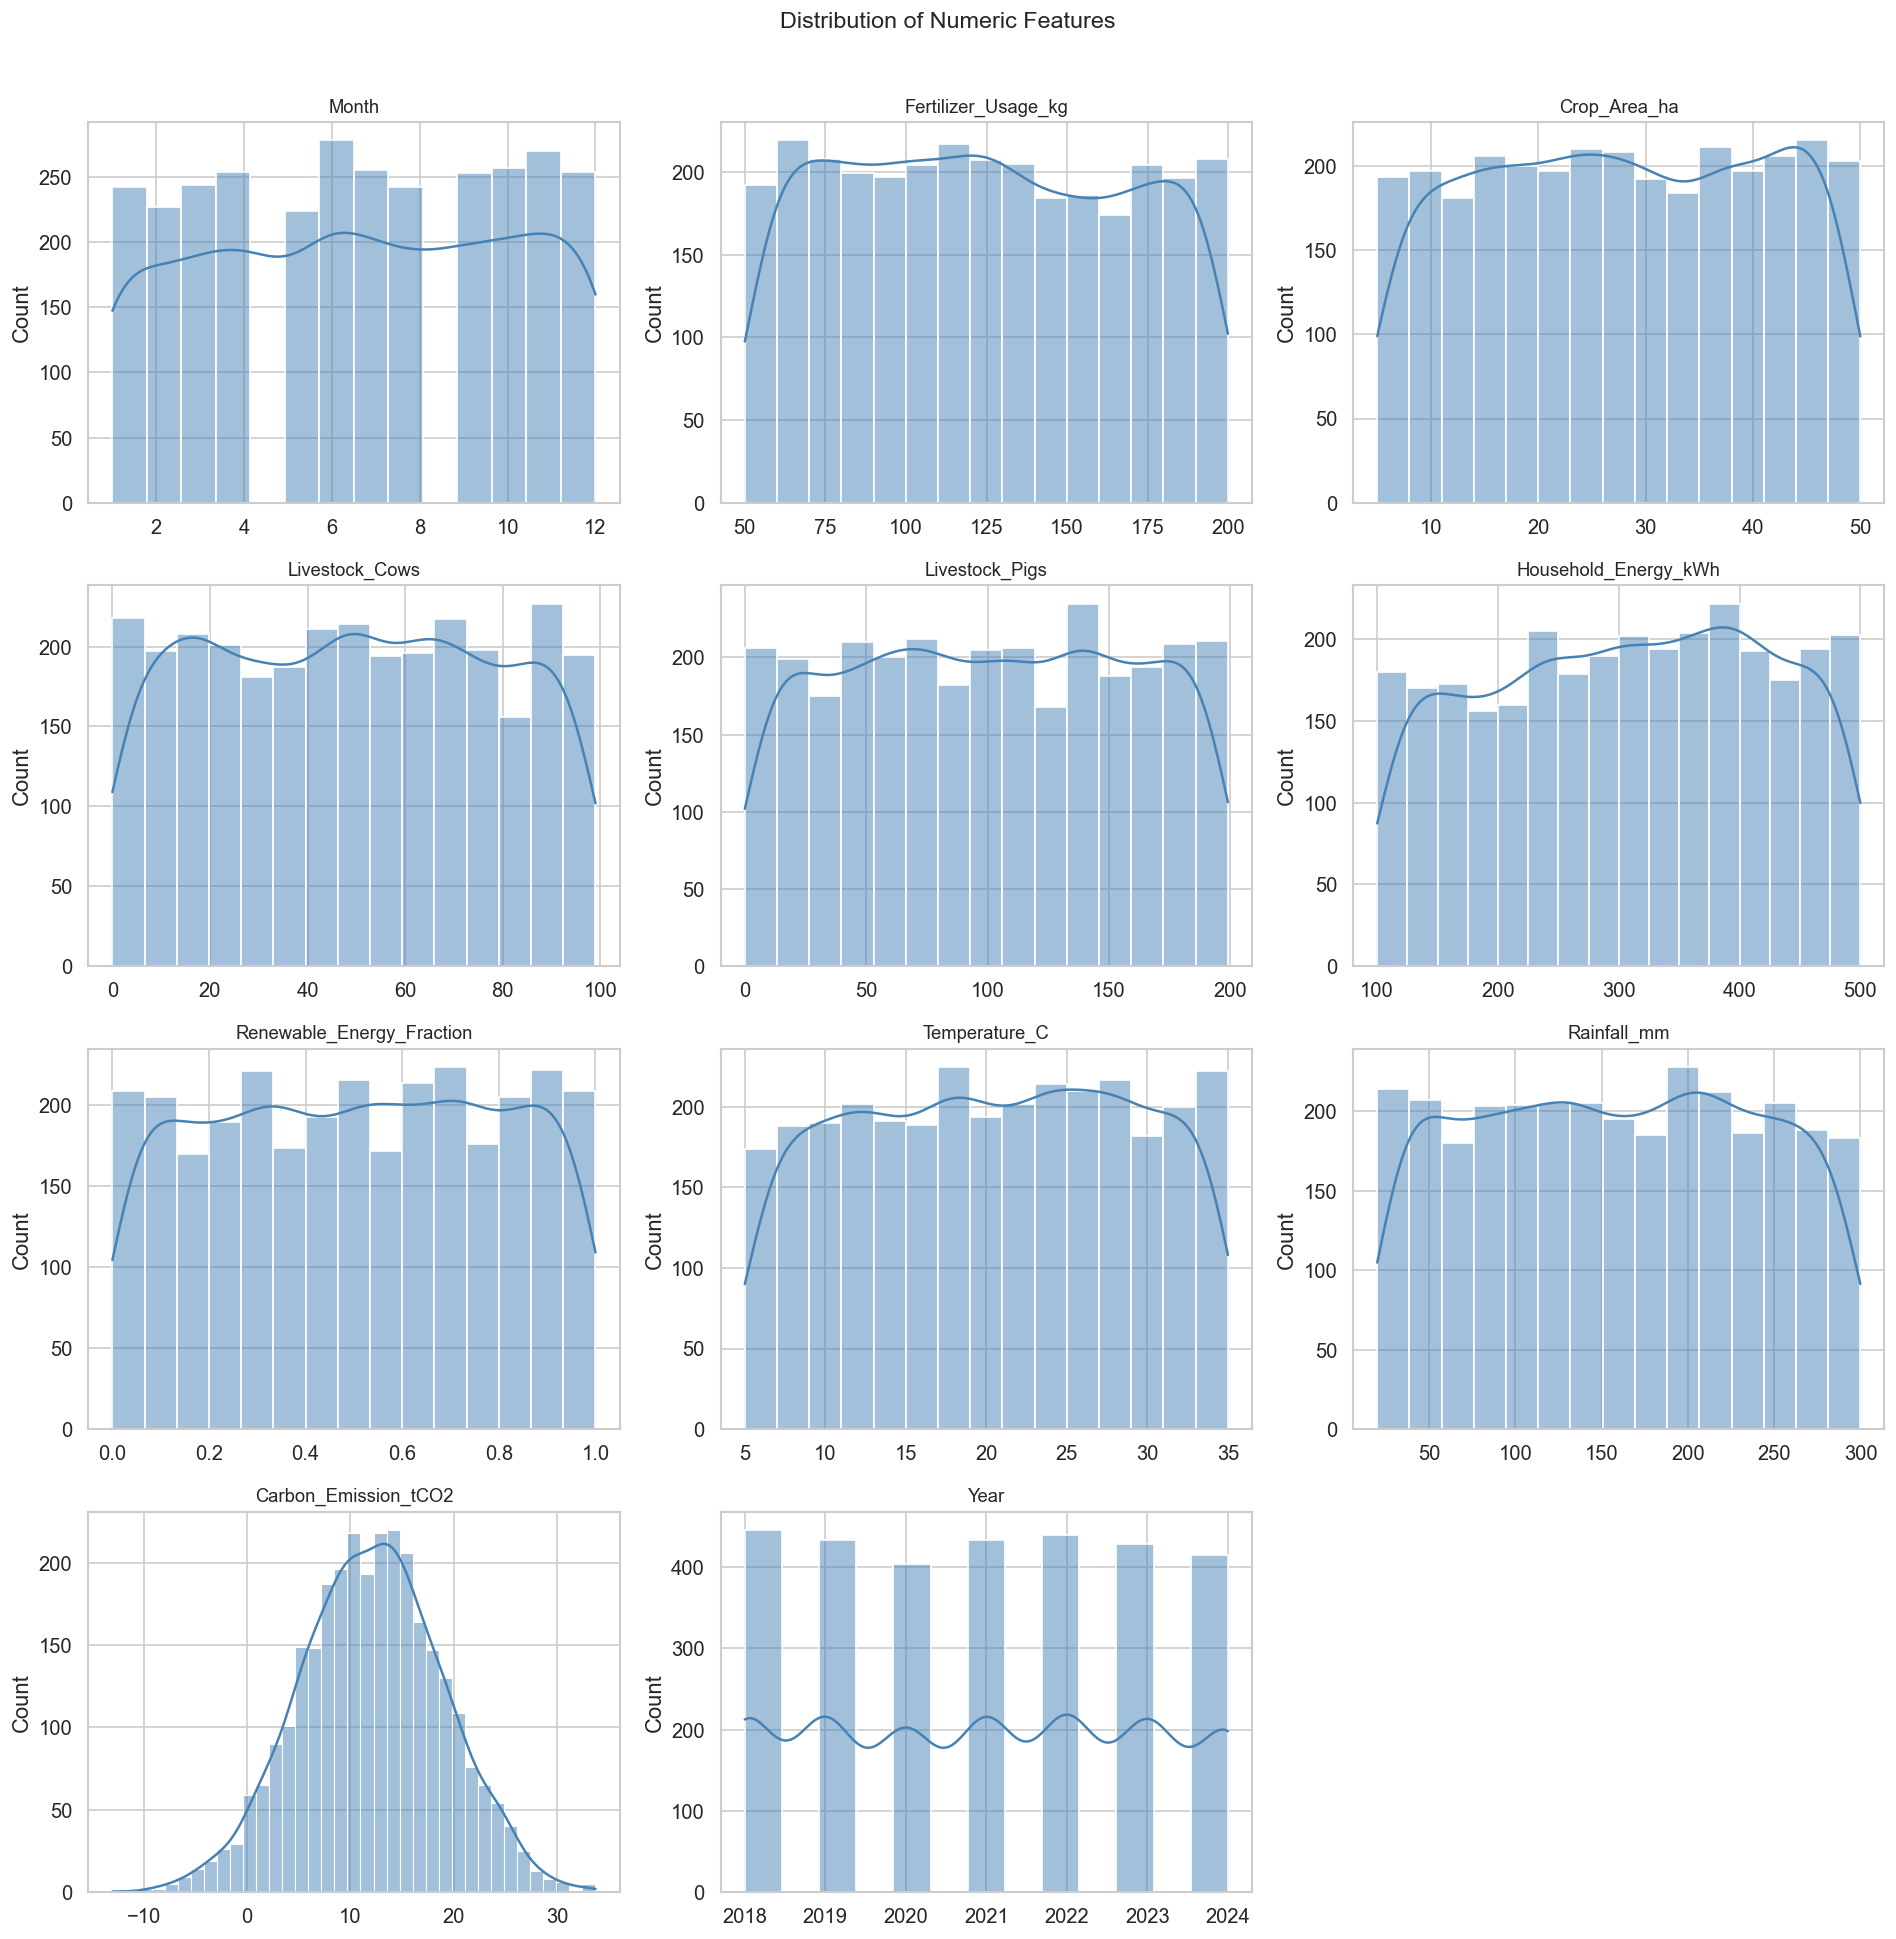

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 4.2 Categorical Features



--- Region ---
Region
R0039    19
R0154    18
R0147    18
R0113    18
R0012    18
         ..
R0299     3
R0185     3
R0094     3
R0091     3
R0071     2
Name: count, Length: 300, dtype: int64


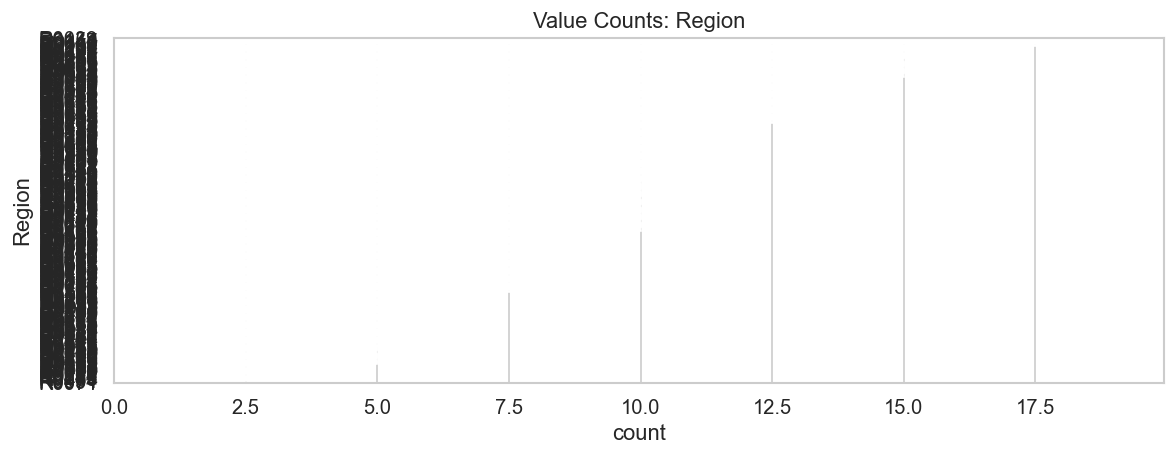


--- Crop_Type ---
Crop_Type
Rice      774
Barley    762
Maize     758
Wheat     706
Name: count, dtype: int64


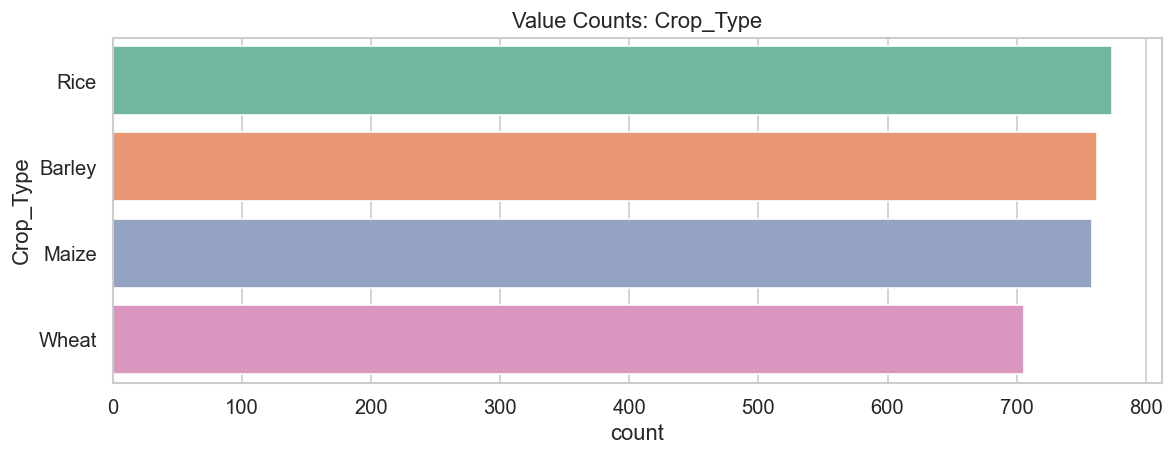

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\n--- {col} ---")
    vc = df[col].value_counts()
    print(vc)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.countplot(data=df, y=col, order=vc.index, palette='Set2', ax=ax)
    ax.set_title(f'Value Counts: {col}')
    plt.tight_layout()
    plt.show()


## 5. Bivariate / Correlation Analysis


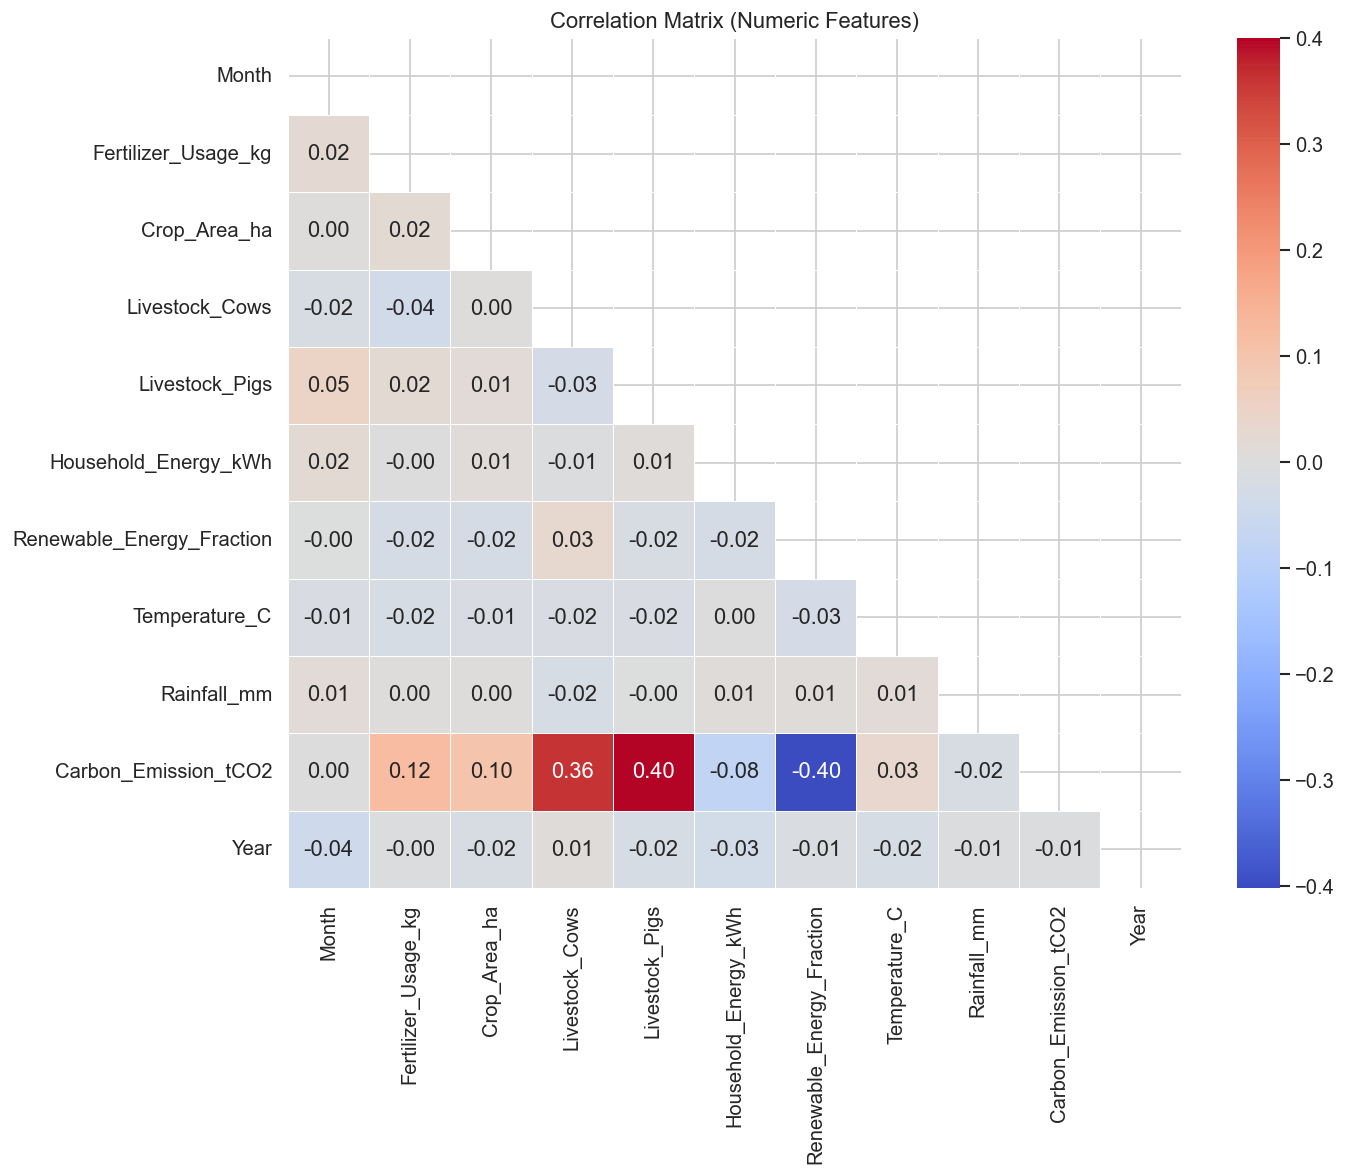

In [9]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()


Correlations with Carbon_Emission_tCO2:

Renewable_Energy_Fraction   -0.401736
Livestock_Pigs               0.400154
Livestock_Cows               0.360564
Fertilizer_Usage_kg          0.121681
Crop_Area_ha                 0.101874
Household_Energy_kWh        -0.076241
Temperature_C                0.032937
Rainfall_mm                 -0.018805
Year                        -0.005828
Month                        0.000049


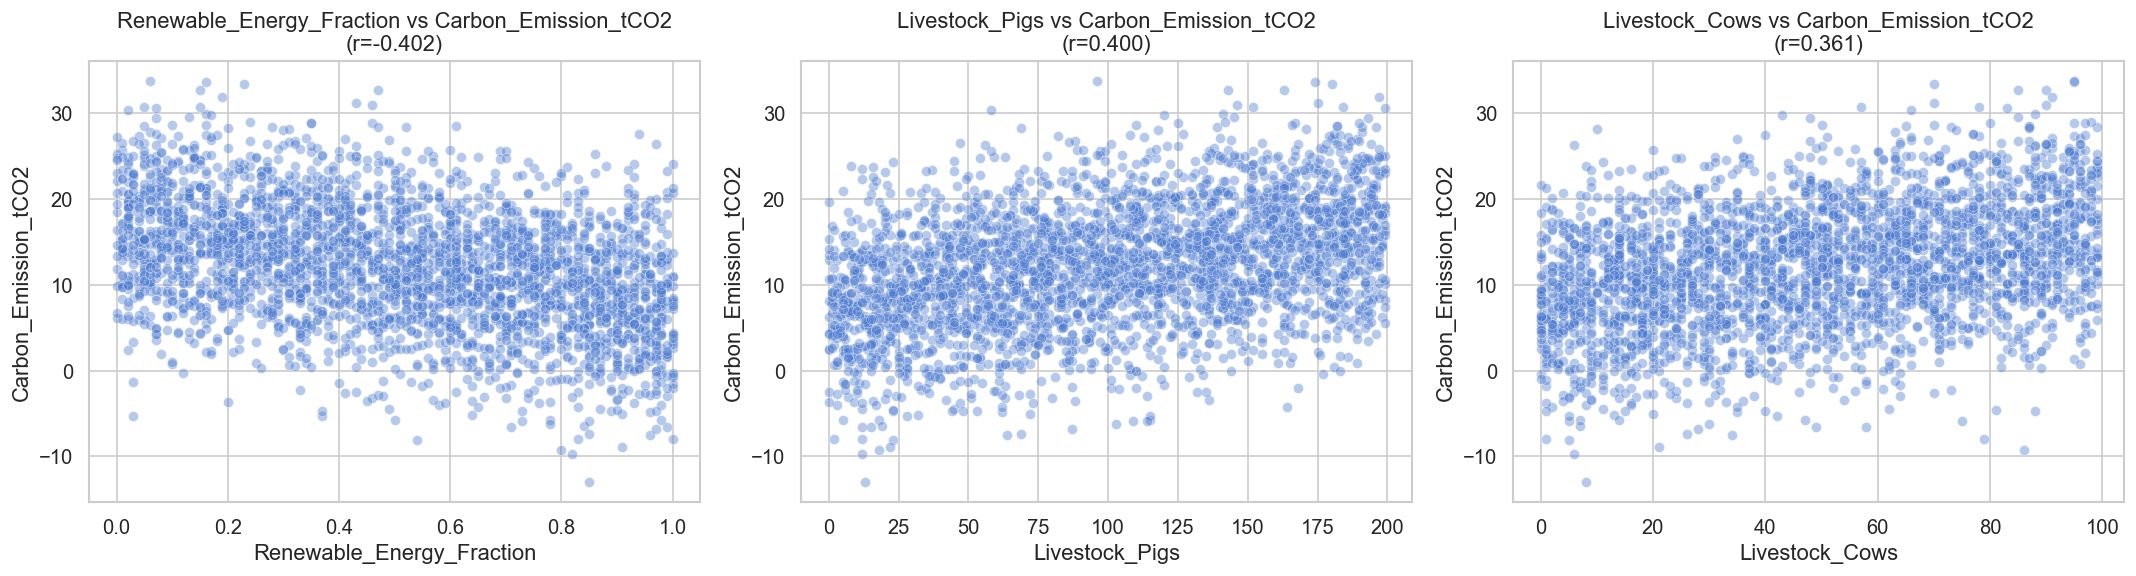

In [10]:
# Top correlations with Carbon_Emission_tCO2 (the likely target)
target = 'Carbon_Emission_tCO2'
if target in df.columns:
    target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)
    print(f"Correlations with {target}:\n")
    print(target_corr.to_string())
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    top3 = target_corr.head(3).index.tolist()
    for i, feat in enumerate(top3):
        sns.scatterplot(data=df, x=feat, y=target, alpha=0.4, ax=axes[i])
        axes[i].set_title(f'{feat} vs {target}\n(r={corr.loc[feat, target]:.3f})')
    plt.tight_layout()
    plt.show()


### 5.1 Carbon Emissions by Region and Crop Type


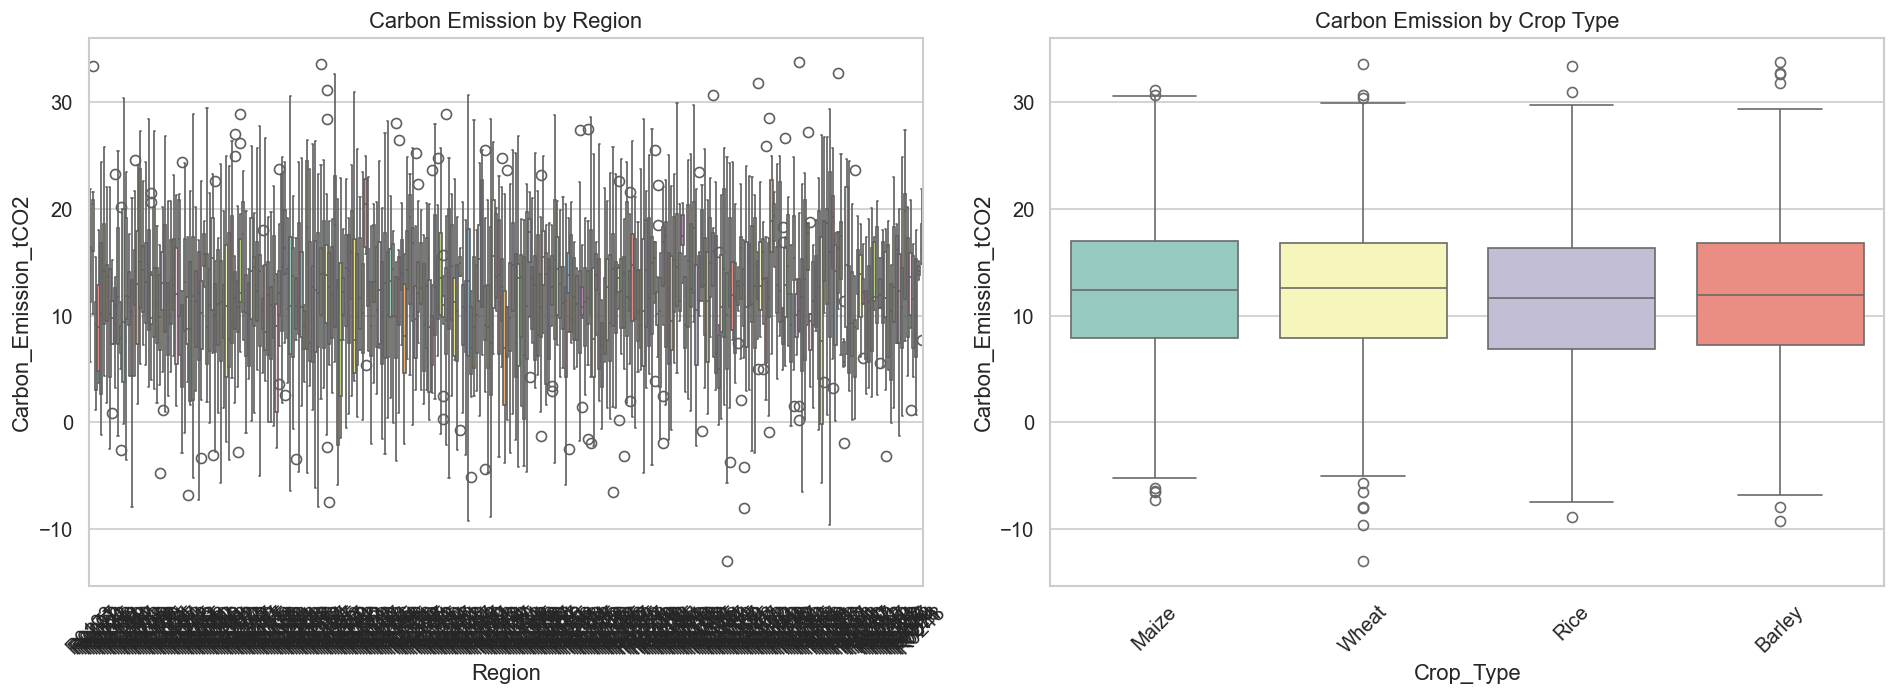

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Region', y='Carbon_Emission_tCO2', ax=axes[0], palette='Set3')
axes[0].set_title('Carbon Emission by Region')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Crop_Type', y='Carbon_Emission_tCO2', ax=axes[1], palette='Set3')
axes[1].set_title('Carbon Emission by Crop Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 5.2 Temporal Patterns


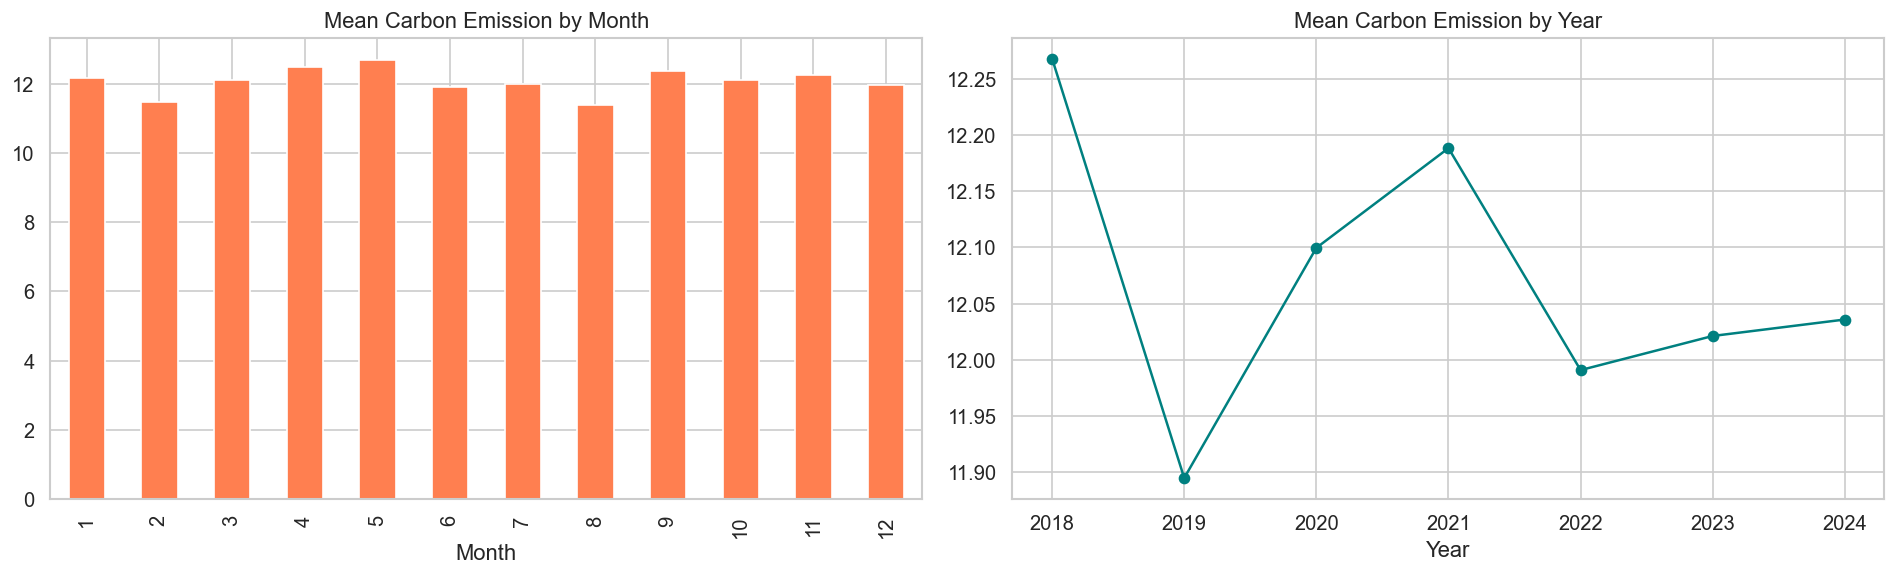

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly = df.groupby('Month')['Carbon_Emission_tCO2'].mean()
monthly.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Mean Carbon Emission by Month')
axes[0].set_xlabel('Month')

yearly = df.groupby('Year')['Carbon_Emission_tCO2'].mean()
yearly.plot(kind='line', marker='o', ax=axes[1], color='teal')
axes[1].set_title('Mean Carbon Emission by Year')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()


## 6. Outlier Detection


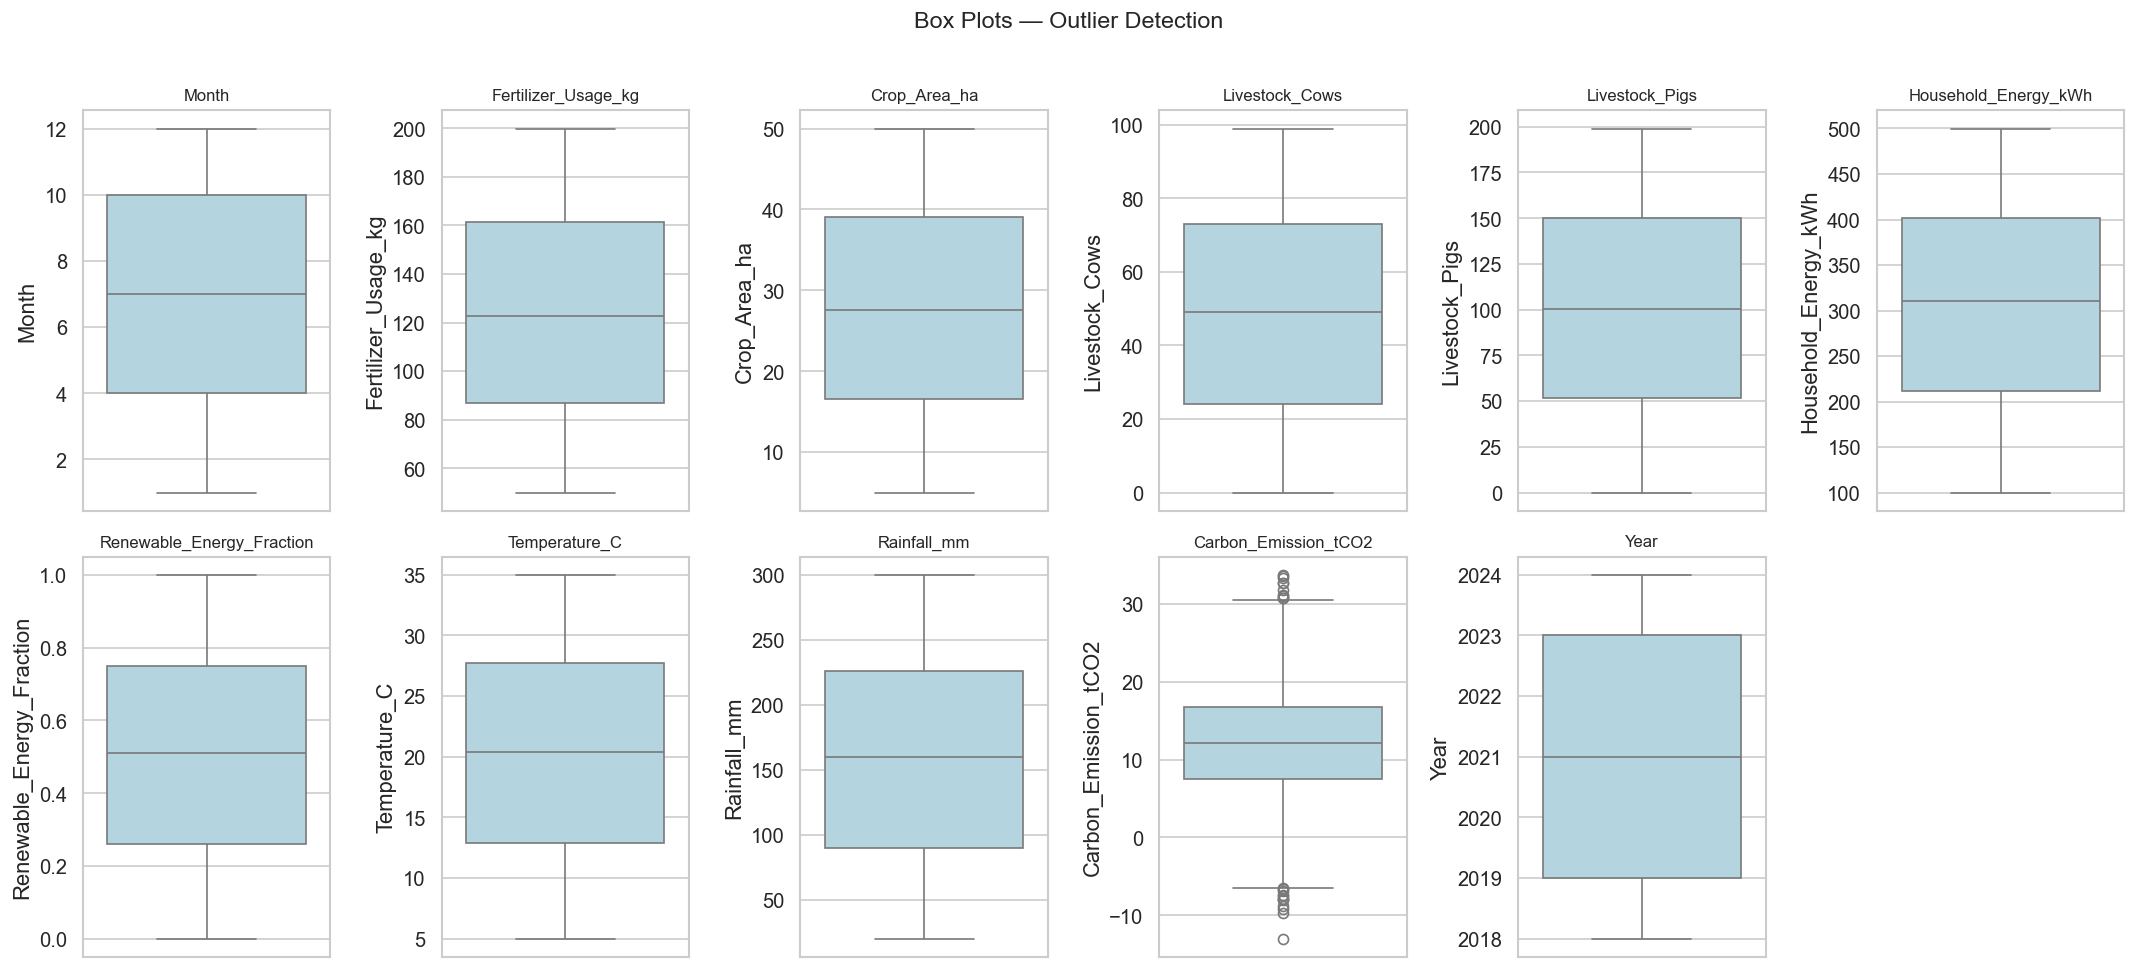

In [13]:
fig, axes = plt.subplots(2, (len(numeric_cols)+1)//2, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightblue')
    axes[i].set_title(col, fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [14]:
# IQR-based outlier counts
print("Outlier counts (IQR method):\n")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f"  {col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")


Outlier counts (IQR method):

  Carbon_Emission_tCO2: 22 outliers (0.7%)


## 7. Key Findings & Summary

### Dataset Summary
- **3,000 rows × 13 columns** — clean dataset with **zero missing values**
- Mix of numeric (11) and categorical (2) features
- Target variable: `Carbon_Emission_tCO2`

### Key Observations
1. **Feature types**: Fertiliser usage, crop area, livestock counts, household energy, renewable energy fraction, temperature, rainfall, and year
2. **Categorical splits**: Region and Crop_Type provide natural groupings
3. **Temporal coverage**: Data spans multiple months and years
4. **Correlations**: Check the correlation matrix above for top predictors of carbon emission
5. **Outliers**: See IQR analysis above — important to handle before modelling

### Action Plan for Modelling
- No imputation needed (no missing values)
- Encode Region and Crop_Type (one-hot or target encoding)
- Consider feature interactions (e.g., livestock × fertiliser)
- Scale numeric features for distance-based models
